# **IEOR 164 Project: Two-Stage Stochastic LLM Routing**

by Yu Hin Liang, Jingwen Yang

# **Environment Setup**

In [1]:
# For Google Colab: install pyomo + highspy. Locally use the kernel that already has them.
import sys
if 'google.colab' in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null

import pyomo.environ as pyo
SOLVER_NAME = 'appsi_highs'
SOLVER = pyo.SolverFactory(SOLVER_NAME)
assert SOLVER.available(False), f'Solver {SOLVER_NAME} not available.'

In [2]:
from pathlib import Path
import math, json, time, itertools
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

In [3]:
# ============================================================
# Configuration
# ============================================================
CSV_PATH = 'routerbench.csv'
OUTPUT_DIR = Path('solution_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Cost-budget grid (USD per prompt) for the BC-2SP frontier sweep.
B_GRID = [1e-5, 1e-4, 3e-4, 5e-4, 1e-3, 2e-3, 5e-3]
K_DEFAULT = 8
EPS_TIEBREAK = 1e-3      # cost tie-breaker so the cost row is monotone in B
RANDOM_SEED = 42

In [4]:
# ============================================================
# Utility functions
# ============================================================
def get_solver():
    s = pyo.SolverFactory(SOLVER_NAME)
    if not s.available(False):
        raise RuntimeError(f'Solver {SOLVER_NAME} not available.')
    return s

def safe_float(x, default=0.0):
    try:
        if pd.isna(x): return default
        return float(x)
    except Exception:
        return default

# **Data loading and preprocessing**

In [5]:
def load_data(csv_path: str = CSV_PATH) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    for c in ['dataset','prompt_id','model']:
        df[c] = df[c].astype(str)
    df['score'] = pd.to_numeric(df['score'], errors='coerce').fillna(0.0)
    df['cost']  = pd.to_numeric(df['cost'],  errors='coerce').fillna(0.0)
    df = df.drop_duplicates(['prompt_id','model']).copy()
    return df

def restrict_to_full_coverage(df):
    n_p = df['prompt_id'].nunique()
    counts = df.groupby('model')['prompt_id'].nunique()
    keep = counts[counts == n_p].index.tolist()
    return df[df['model'].isin(keep)].copy()

def make_dicts(df):
    Q, C, dom = {}, {}, {}
    for _, r in df.iterrows():
        Q[(r['prompt_id'], r['model'])] = float(r['score'])
        C[(r['prompt_id'], r['model'])] = float(r['cost'])
        dom[r['prompt_id']] = r['dataset']
    prompts = sorted(df['prompt_id'].unique())
    models  = sorted(df['model'].unique())
    datasets= sorted(df['dataset'].unique())
    return prompts, models, datasets, Q, C, dom

def make_uniform_weights(prompts):
    return {p: 1.0/len(prompts) for p in prompts}

def estimate_storage_gb(name):
    n = name.lower()
    flagship = ('gpt-5','gpt-5-chat','claude-sonnet-4','gemini-2.5-pro',
                'gemini-2.5-flash','glm-4.6')
    if any(k in n for k in flagship):                  return 0.0
    if '235b' in n:                                    return 470.0
    if 'deepseek-v3' in n or 'deepseek-r1' in n or 'kimi-k2' in n: return 0.0
    if any(s in n for s in ('9b','9-b')):              return 18.0
    if any(s in n for s in ('8b','8-b')):              return 16.0
    if any(s in n for s in ('7b','7-b')):              return 14.0
    if 'intern-s1' == n.split('-')[0]:                 return 0.0
    return 12.0

# **Baseline policies**

In [6]:
def oracle_routing(df, weights):
    rows = []
    for p, sub in df.groupby('prompt_id'):
        max_s = sub['score'].max()
        cand = sub[sub['score'] == max_s].sort_values('cost').iloc[0]
        rows.append({'prompt_id': p, 'model': cand['model'], 'dataset': cand['dataset'],
                     'weight': weights[p], 'score': float(cand['score']),
                     'cost': float(cand['cost'])})
    a = pd.DataFrame(rows)
    return {'policy': 'Oracle (per-prompt best)',
            'avg_cost':  float((a['weight']*a['cost']).sum()),
            'avg_score': float((a['weight']*a['score']).sum()),
            'assignments': a}

def single_best(df, weights):
    rows = []
    for m, sub in df.groupby('model'):
        wp = sub['prompt_id'].map(weights)
        rows.append({'model': m,
                     'avg_cost': float((wp*sub['cost']).sum()),
                     'avg_score': float((wp*sub['score']).sum())})
    return pd.DataFrame(rows).sort_values('avg_score', ascending=False).reset_index(drop=True)

def single_best_per_benchmark(df, weights):
    rows = []; chosen = {}
    for d, sub in df.groupby('dataset'):
        prompts_d = sub['prompt_id'].unique()
        cand = []
        for m, sub_m in sub.groupby('model'):
            if set(sub_m['prompt_id']) != set(prompts_d): continue
            wd = sub_m['prompt_id'].map(weights)
            cand.append({'model': m, 'score': float((wd*sub_m['score']).sum()),
                         'cost':  float((wd*sub_m['cost']).sum())})
        c = pd.DataFrame(cand).sort_values(['score','cost'], ascending=[False, True])
        best_m = c.iloc[0]['model']; chosen[d] = best_m
        for _, r in sub[sub['model']==best_m].iterrows():
            rows.append({'prompt_id': r['prompt_id'], 'model': best_m, 'dataset': d,
                         'weight': weights[r['prompt_id']],
                         'score': float(r['score']), 'cost': float(r['cost'])})
    a = pd.DataFrame(rows)
    return {'policy': 'Single Best per Benchmark',
            'selected_per_dataset': chosen,
            'avg_cost':  float((a['weight']*a['cost']).sum()),
            'avg_score': float((a['weight']*a['score']).sum()),
            'assignments': a}

# **BC-2SP: Budget-Constrained Two-Stage Stochastic MILP**

In [7]:
def solve_bc2sp(
    df: pd.DataFrame,
    weights: dict,
    *,
    B: float | None = None,                 # cost budget; None = no budget
    K: int | None = None,                   # pool-size cap
    S_max: float | None = None,             # storage budget (GB)
    fairness_tau: float | None = None,      # per-prompt min quality with slack
    lambda_slack: float = 1.0,              # slack penalty in objective
    must_include: Iterable[str] = (),
    must_exclude: Iterable[str] = (),
    randomized: bool = False,               # x in [0,1] (LP relax)
    quiet: bool = True,
):
    """
    max  sum_p w_p sum_m Q_pm x_pm  -  lambda * sum_p w_p s_p
    s.t. sum_m x_pm = 1                                        (assignment)
         x_pm <= y_m                                            (linking)
         sum_m y_m <= K                                         (pool size)
         sum_m S_m y_m <= S_max                                 (storage)
         sum_{p,m} w_p C_pm x_pm <= B                          (budget)
         sum_m Q_pm x_pm + s_p >= tau,  s_p >= 0               (fairness)
         y_m = 1 for m in must_include; y_m = 0 for m in must_exclude
    """
    prompts, models, datasets, Q, C, dom = make_dicts(df)
    storage = {m: estimate_storage_gb(m) for m in models}

    mdl = pyo.ConcreteModel()
    mdl.P = pyo.Set(initialize=prompts)
    mdl.M = pyo.Set(initialize=models)

    mdl.w = pyo.Param(mdl.P, initialize=weights, within=pyo.NonNegativeReals)
    # Note: we index Q,C over P×M assuming full coverage (we restrict df beforehand).
    mdl.Q = pyo.Param(mdl.P, mdl.M, initialize={(p, m): Q[(p, m)] for p in prompts for m in models})
    mdl.C = pyo.Param(mdl.P, mdl.M, initialize={(p, m): C[(p, m)] for p in prompts for m in models})
    mdl.S = pyo.Param(mdl.M, initialize=storage)

    if randomized:
        mdl.x = pyo.Var(mdl.P, mdl.M, within=pyo.NonNegativeReals, bounds=(0, 1))
    else:
        mdl.x = pyo.Var(mdl.P, mdl.M, within=pyo.Binary)
    mdl.y = pyo.Var(mdl.M, within=pyo.Binary)

    if fairness_tau is not None:
        mdl.s = pyo.Var(mdl.P, within=pyo.NonNegativeReals)

    mdl.assign = pyo.Constraint(mdl.P, rule=lambda m, p: sum(m.x[p, k] for k in m.M) == 1)
    mdl.link = pyo.Constraint(mdl.P, mdl.M, rule=lambda m, p, k: m.x[p, k] <= m.y[k])

    if K is not None:
        mdl.pool_cap = pyo.Constraint(rule=lambda m: sum(m.y[k] for k in m.M) <= K)
    if S_max is not None:
        mdl.storage_cap = pyo.Constraint(rule=lambda m: sum(m.S[k] * m.y[k] for k in m.M) <= S_max)
    if B is not None:
        mdl.budget = pyo.Constraint(
            rule=lambda m: sum(m.w[p] * m.C[p, k] * m.x[p, k] for p in m.P for k in m.M) <= B
        )
    if fairness_tau is not None:
        mdl.fair = pyo.Constraint(
            mdl.P,
            rule=lambda m, p: sum(m.Q[p, k] * m.x[p, k] for k in m.M) + m.s[p] >= fairness_tau,
        )
    for inc in must_include:
        if inc in models:
            mdl.y[inc].fix(1)
    for exc in must_exclude:
        if exc in models:
            mdl.y[exc].fix(0)

    score_expr = sum(mdl.w[p] * mdl.Q[p, k] * mdl.x[p, k] for p in mdl.P for k in mdl.M)
    cost_expr = sum(mdl.w[p] * mdl.C[p, k] * mdl.x[p, k] for p in mdl.P for k in mdl.M)
    eps_cost = 1e-3  # tie-breaker: at score-saturation, prefer lower cost
    if fairness_tau is not None:
        slack_expr = sum(mdl.w[p] * mdl.s[p] for p in mdl.P)
        mdl.obj = pyo.Objective(
            expr=score_expr - lambda_slack * slack_expr - eps_cost * cost_expr,
            sense=pyo.maximize,
        )
    else:
        mdl.obj = pyo.Objective(expr=score_expr - eps_cost * cost_expr, sense=pyo.maximize)

    solver = get_solver()
    res = solver.solve(mdl, tee=False)

    selected_pool = [k for k in models if pyo.value(mdl.y[k]) > 0.5]
    rows = []
    for p in prompts:
        for k in models:
            xv = pyo.value(mdl.x[p, k])
            if xv > 1e-6:
                rows.append({
                    "prompt_id": p, "model": k, "dataset": dom[p],
                    "weight": weights[p], "x": xv, "score": Q[(p, k)], "cost": C[(p, k)],
                })
    a = pd.DataFrame(rows)
    avg_cost = float((a["weight"] * a["x"] * a["cost"]).sum())
    avg_score = float((a["weight"] * a["x"] * a["score"]).sum())
    return {
        "policy": ("Randomized BC-2SP" if randomized else "BC-2SP")
                  + ("" if fairness_tau is None else " + fairness")
                  + ("" if S_max is None else " + storage")
                  + ("" if K is None else f" (K={K})")
                  + ("" if B is None else f" (B={B:.4g})"),
        "B": B, "K": K, "S_max": S_max, "tau": fairness_tau, "lambda": lambda_slack,
        "selected_pool": selected_pool,
        "pool_size": len(selected_pool),
        "avg_cost": avg_cost,
        "avg_score": avg_score,
        "assignments": a,
        "obj_value": pyo.value(mdl.obj),
        "solver_status": str(res.solver.status),
        "term": str(res.solver.termination_condition),
    }

# **QC-2SP: cost minimization under quality target**

In [8]:
def solve_qc2sp(
    df, weights, *,
    Q_target: float,
    K: int | None = None, S_max: float | None = None,
    must_include=(), must_exclude=(),
):
    prompts, models, datasets, Q, C, dom = make_dicts(df)
    storage = {m: estimate_storage_gb(m) for m in models}
    mdl = pyo.ConcreteModel()
    mdl.P = pyo.Set(initialize=prompts)
    mdl.M = pyo.Set(initialize=models)
    mdl.w = pyo.Param(mdl.P, initialize=weights)
    mdl.Q = pyo.Param(mdl.P, mdl.M, initialize={(p, m): Q[(p, m)] for p in prompts for m in models})
    mdl.C = pyo.Param(mdl.P, mdl.M, initialize={(p, m): C[(p, m)] for p in prompts for m in models})
    mdl.S = pyo.Param(mdl.M, initialize=storage)
    mdl.x = pyo.Var(mdl.P, mdl.M, within=pyo.Binary)
    mdl.y = pyo.Var(mdl.M, within=pyo.Binary)
    mdl.assign = pyo.Constraint(mdl.P, rule=lambda m, p: sum(m.x[p, k] for k in m.M) == 1)
    mdl.link = pyo.Constraint(mdl.P, mdl.M, rule=lambda m, p, k: m.x[p, k] <= m.y[k])
    mdl.qual = pyo.Constraint(
        rule=lambda m: sum(m.w[p] * m.Q[p, k] * m.x[p, k] for p in m.P for k in m.M) >= Q_target
    )
    if K is not None:
        mdl.pool_cap = pyo.Constraint(rule=lambda m: sum(m.y[k] for k in m.M) <= K)
    if S_max is not None:
        mdl.stor = pyo.Constraint(rule=lambda m: sum(m.S[k] * m.y[k] for k in m.M) <= S_max)
    for inc in must_include:
        if inc in models:
            mdl.y[inc].fix(1)
    for exc in must_exclude:
        if exc in models:
            mdl.y[exc].fix(0)
    mdl.obj = pyo.Objective(
        expr=sum(mdl.w[p] * mdl.C[p, k] * mdl.x[p, k] for p in mdl.P for k in mdl.M),
        sense=pyo.minimize,
    )
    res = get_solver().solve(mdl, tee=False)
    if str(res.solver.termination_condition) != "optimal":
        return {"policy": "QC-2SP", "Q_target": Q_target, "infeasible": True,
                "term": str(res.solver.termination_condition)}
    pool = [k for k in models if pyo.value(mdl.y[k]) > 0.5]
    rows = []
    for p in prompts:
        for k in models:
            if pyo.value(mdl.x[p, k]) > 0.5:
                rows.append({"prompt_id": p, "model": k, "dataset": dom[p],
                             "weight": weights[p], "score": Q[(p, k)], "cost": C[(p, k)]})
    a = pd.DataFrame(rows)
    return {
        "policy": "QC-2SP",
        "Q_target": Q_target, "K": K, "S_max": S_max,
        "selected_pool": pool, "pool_size": len(pool),
        "avg_cost": float((a["weight"] * a["cost"]).sum()),
        "avg_score": float((a["weight"] * a["score"]).sum()),
        "assignments": a,
    }

# **DRO BC-2SP: box ambiguity over benchmark proportions**

In [9]:
def solve_dro_bc2sp(
    df, prompts_uniform_weights, *,
    B: float, K: int | None = None, S_max: float | None = None,
    delta: float = 0.3,
):
    """
    Distributionally robust BC-2SP with a relative-box ambiguity set on the
    benchmark mixture w_d := Pr[xi in P_d] around w_d^0 = |P_d| / |P|:

        U(delta) = { w in simplex : |w_d - w_d^0| <= delta * w_d^0 ∀ d }.

    Within each domain prompts are uniformly weighted. Let
        f_d(x) := (1/|P_d|) sum_{p in P_d, m} Q_pm x_pm
    be the conditional score on domain d. The DRO problem is

        max_{y, x} min_{w in U(delta)} sum_d w_d f_d(x).

    Reparametrising w_d = w_d^0 (1 + e_d) with sum_d w_d^0 e_d = 0 and
    |e_d| <= delta, the inner LP has dual minimum
        min_w sum_d w_d f_d(x)
            = sum_d w_d^0 f_d(x)  -  delta * min_lambda sum_d w_d^0 |f_d - lambda|.

    Linearising the absolute value gives the equivalent MILP:

        max_{y, x, lambda, z}  sum_d w_d^0 f_d(x)  -  delta * sum_d w_d^0 z_d
        s.t.  z_d >= f_d(x) - lambda,  z_d >= lambda - f_d(x), ∀ d
              (BC-2SP constraints) and budget under nominal w.

    This adds |D|+1 variables and 2|D| constraints to BC-2SP.
    """
    prompts, models, datasets, Q, C, dom = make_dicts(df)
    storage = {m: estimate_storage_gb(m) for m in models}
    P_d = {d: [p for p in prompts if dom[p] == d] for d in datasets}
    nominal_d = {d: len(P_d[d]) / len(prompts) for d in datasets}  # = 1/|D| under uniform empirical

    mdl = pyo.ConcreteModel()
    mdl.P = pyo.Set(initialize=prompts)
    mdl.M = pyo.Set(initialize=models)
    mdl.D = pyo.Set(initialize=datasets)
    mdl.Q = pyo.Param(mdl.P, mdl.M, initialize={(p, m): Q[(p, m)] for p in prompts for m in models})
    mdl.C = pyo.Param(mdl.P, mdl.M, initialize={(p, m): C[(p, m)] for p in prompts for m in models})
    mdl.S = pyo.Param(mdl.M, initialize=storage)
    mdl.w_nominal = pyo.Param(mdl.P, initialize=prompts_uniform_weights)

    mdl.x = pyo.Var(mdl.P, mdl.M, within=pyo.Binary)
    mdl.y = pyo.Var(mdl.M, within=pyo.Binary)
    mdl.lam = pyo.Var(within=pyo.Reals)
    mdl.z = pyo.Var(mdl.D, within=pyo.NonNegativeReals)

    mdl.assign = pyo.Constraint(mdl.P, rule=lambda m, p: sum(m.x[p, k] for k in m.M) == 1)
    mdl.link = pyo.Constraint(mdl.P, mdl.M, rule=lambda m, p, k: m.x[p, k] <= m.y[k])
    if K is not None:
        mdl.pool_cap = pyo.Constraint(rule=lambda m: sum(m.y[k] for k in m.M) <= K)
    if S_max is not None:
        mdl.stor = pyo.Constraint(rule=lambda m: sum(m.S[k] * m.y[k] for k in m.M) <= S_max)
    mdl.budget = pyo.Constraint(
        rule=lambda m: sum(m.w_nominal[p] * m.C[p, k] * m.x[p, k] for p in m.P for k in m.M) <= B
    )

    # Conditional scores f_d(x), as Pyomo expressions (constructed lazily below).
    def f_d_expr(m, d):
        return (1.0 / len(P_d[d])) * sum(m.Q[p, k] * m.x[p, k] for p in P_d[d] for k in m.M)

    mdl.z_pos = pyo.Constraint(mdl.D, rule=lambda m, d: m.z[d] >= f_d_expr(m, d) - m.lam)
    mdl.z_neg = pyo.Constraint(mdl.D, rule=lambda m, d: m.z[d] >= m.lam - f_d_expr(m, d))

    nominal_score = sum(nominal_d[d] * f_d_expr(mdl, d) for d in datasets)
    mad_penalty = sum(nominal_d[d] * mdl.z[d] for d in datasets)
    mdl.obj = pyo.Objective(expr=nominal_score - delta * mad_penalty, sense=pyo.maximize)

    res = get_solver().solve(mdl, tee=False)
    pool = [k for k in models if pyo.value(mdl.y[k]) > 0.5]

    rows = []
    for p in prompts:
        for k in models:
            if pyo.value(mdl.x[p, k]) > 0.5:
                rows.append({"prompt_id": p, "model": k, "dataset": dom[p],
                             "weight": prompts_uniform_weights[p],
                             "score": Q[(p, k)], "cost": C[(p, k)]})
    a = pd.DataFrame(rows)
    worst_case = float(pyo.value(mdl.obj))
    return {
        "policy": "DRO BC-2SP",
        "B": B, "K": K, "S_max": S_max, "delta": delta,
        "selected_pool": pool, "pool_size": len(pool),
        "avg_cost_nominal": float((a["weight"] * a["cost"]).sum()),
        "avg_score_nominal": float((a["weight"] * a["score"]).sum()),
        "worst_case_score": worst_case,
        "lambda_star": float(pyo.value(mdl.lam)),
        "assignments": a,
    }

# **Plotting Functionality**

In [10]:
ALPHA_GRID = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

def alpha_sweep_oracle(df, weights):
    prompts, models, _, Q, C, _ = make_dicts(df)
    rows = []
    for a in ALPHA_GRID:
        cost = score = 0.0
        for p in prompts:
            best = min(models, key=lambda m: C[(p,m)] - a*Q[(p,m)])
            cost  += weights[p] * C[(p, best)]
            score += weights[p] * Q[(p, best)]
        rows.append({'alpha': a, 'avg_cost': cost, 'avg_score': score})
    return pd.DataFrame(rows)

def alpha_sweep_single_best(df, weights):
    rows = []
    for a in ALPHA_GRID:
        best_obj = best_c = best_s = None
        for m, sub in df.groupby('model'):
            wp = sub['prompt_id'].map(weights)
            sm = (wp*sub['score']).sum(); cm = (wp*sub['cost']).sum()
            obj = cm - a*sm
            if best_obj is None or obj < best_obj:
                best_obj, best_c, best_s = obj, cm, sm
        rows.append({'alpha': a, 'avg_cost': best_c, 'avg_score': best_s})
    return pd.DataFrame(rows)

def alpha_sweep_single_best_per_benchmark(df, weights):
    rows = []
    for a in ALPHA_GRID:
        total_c = total_s = 0.0
        for d, sub in df.groupby('dataset'):
            best_obj = best_c = best_s = None
            for m, sub_m in sub.groupby('model'):
                wp = sub_m['prompt_id'].map(weights)
                sm = (wp*sub_m['score']).sum(); cm = (wp*sub_m['cost']).sum()
                obj = cm - a*sm
                if best_obj is None or obj < best_obj:
                    best_obj, best_c, best_s = obj, cm, sm
            total_c += best_c; total_s += best_s
        rows.append({'alpha': a, 'avg_cost': total_c, 'avg_score': total_s})
    return pd.DataFrame(rows)

def plot_frontier(df_oracle, df_sb, df_sbb, df_bc, output_path):
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    ax.plot(df_oracle['avg_cost'], df_oracle['avg_score'],
            'o-', color='C0', lw=2.0, label='Oracle (per-prompt best)')
    ax.plot(df_sb['avg_cost'], df_sb['avg_score'],
            's--', color='C1', lw=1.6, label='Single Best')
    ax.plot(df_sbb['avg_cost'], df_sbb['avg_score'],
            '^--', color='C2', lw=1.6, label='Single Best per Benchmark')
    ax.plot(df_bc['avg_cost'], df_bc['avg_score'],
            'D-.', color='C3', lw=2.0, label='BC-2SP (ours)')
    ax.set_xlabel('Weighted Average Cost (USD per prompt)')
    ax.set_ylabel('Weighted Average Score')
    ax.set_title('Routing Policies on the Cost-Performance Plane')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right')
    fig.tight_layout(); fig.savefig(output_path, dpi=180)
    plt.show()

# **Experiments**

In [11]:
df = restrict_to_full_coverage(load_data(CSV_PATH))
prompts, models, datasets, Q_all, C_all, dom = make_dicts(df)
weights = make_uniform_weights(prompts)
print(f'prompts={len(prompts)}, models={len(models)}, datasets={datasets}')

oracle = oracle_routing(df, weights)
sb_table = single_best(df, weights)
sbb = single_best_per_benchmark(df, weights)
print(f'Oracle: score={oracle["avg_score"]:.4f}, cost=${oracle["avg_cost"]:.6f}')
print(f'Best single model: {sb_table.iloc[0]["model"]} -> '
      f'score={sb_table.iloc[0]["avg_score"]:.4f}, cost=${sb_table.iloc[0]["avg_cost"]:.6f}')
print(f'SBB: score={sbb["avg_score"]:.4f}, cost=${sbb["avg_cost"]:.6f}')

prompts=240, models=32, datasets=['AIME', 'GPQA', 'LCB', 'MMLU-Pro']


Oracle: score=0.9833, cost=$0.001699
Best single model: gpt-5 -> score=0.8875, cost=$0.042548
SBB: score=0.8875, cost=$0.037823


In [12]:
# BC-2SP cost-quality frontier
rows = []
for B in B_GRID:
    r = solve_bc2sp(df, weights, B=B, K=K_DEFAULT)
    rows.append({'B': B, 'avg_cost': r['avg_cost'], 'avg_score': r['avg_score'],
                 'pool_size': r['pool_size'], 'pool': '|'.join(r['selected_pool'])})
df_bc = pd.DataFrame(rows)
df_bc

,B,avg_cost,avg_score,pool_size,pool
0,0.00001,0.000010,0.891667,8,GLM-Z1-9B-0414|Llama-3.1-8B-Instruct|Llama-3.1...
1,0.00010,0.000089,0.929167,8,GLM-Z1-9B-0414|Llama-3.1-8B-Instruct|MiniCPM4....
2,0.00030,0.000229,0.954167,8,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...
3,0.00050,0.000229,0.954167,8,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...
4,0.00100,0.000822,0.966667,8,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...
5,0.00200,0.001674,0.975000,8,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...
6,0.00500,0.003233,0.983333,8,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...


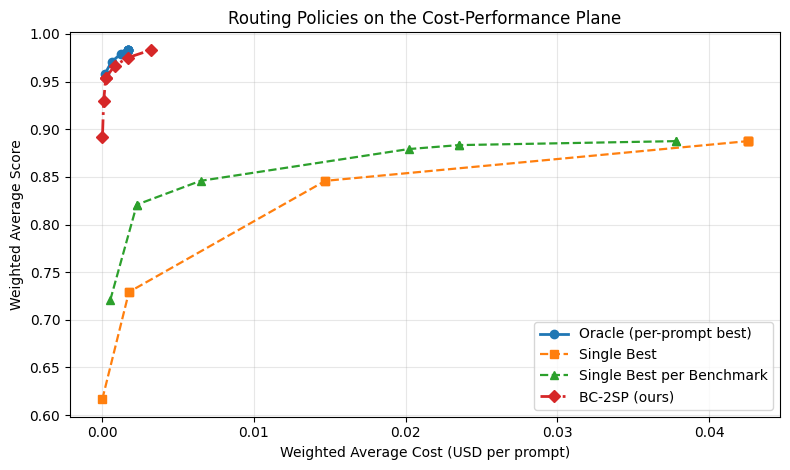

In [13]:
# Alpha-swept curves for the comparison plot
df_oracle = alpha_sweep_oracle(df, weights)
df_sb     = alpha_sweep_single_best(df, weights)
df_sbb    = alpha_sweep_single_best_per_benchmark(df, weights)
plot_frontier(df_oracle, df_sb, df_sbb, df_bc, OUTPUT_DIR / 'frontier.png')

In [14]:
# RQ1: diminishing returns of K
K_grid = list(range(1, 11))
rows = []
for K in K_grid:
    r = solve_bc2sp(df, weights, B=5e-3, K=K)
    rows.append({'K': K, 'avg_score': r['avg_score'], 'avg_cost': r['avg_cost'],
                 'pool_size': r['pool_size'], 'pool': '|'.join(r['selected_pool'])})
df_K = pd.DataFrame(rows); df_K

,K,avg_score,avg_cost,pool_size,pool
0,1,0.741667,0.004704,1,gpt-5-chat
1,2,0.891667,0.004886,2,MiniCPM4.1-8B|qwen3-235b-a22b-thinking-2507
2,3,0.925000,0.004953,3,deepseek-r1-0528|intern-s1|qwen3-235b-a22b-2507
3,4,0.945833,0.003922,4,Llama-3.1-8B-Instruct|deepseek-v3-0324|kimi-k2...
4,5,0.962500,0.004553,5,GLM-Z1-9B-0414|Llama-3.1-8B-Instruct|gpt-5|kim...
5,6,0.979167,0.004690,6,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|glm-4...
6,7,0.983333,0.004519,7,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|gemin...
7,8,0.983333,0.003233,8,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...
8,9,0.983333,0.002635,9,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...
9,10,0.983333,0.002273,10,GLM-Z1-9B-0414|Intern-S1-mini|Llama-3.1-8B-Ins...


In [15]:
# RQ2: distributional robustness
rows = []
for delta in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]:
    r = solve_dro_bc2sp(df, weights, B=5e-3, K=K_DEFAULT, delta=delta)
    rows.append({'delta': delta, 'nominal_score': r['avg_score_nominal'],
                 'worst_case_score': r['worst_case_score'],
                 'pool_size': r['pool_size'], 'pool': '|'.join(r['selected_pool'])})
df_dro = pd.DataFrame(rows); df_dro

,delta,nominal_score,worst_case_score,pool_size,pool
0,0.0,0.983333,0.983333,8,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|MiniC...
1,0.1,0.983333,0.981667,8,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|MiniC...
2,0.2,0.983333,0.980000,8,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|MiniC...
3,0.3,0.983333,0.978333,8,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|MiniC...
4,0.5,0.983333,0.975000,8,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|MiniC...
5,0.7,0.983333,0.971667,8,GLM-Z1-9B-0414|Llama-3.1-8B-UltraMedical|MiniC...


In [16]:
# Constraint ablations: storage and provider rules
rows = []
for S_max in [None, 50, 20]:
    r = solve_bc2sp(df, weights, B=5e-3, K=K_DEFAULT, S_max=S_max)
    rows.append({'S_max_GB': S_max if S_max else 'inf',
                 'avg_score': r['avg_score'], 'avg_cost': r['avg_cost'],
                 'pool_size': r['pool_size']})
for setting, kwargs in [('free', {}),
                         ('no OpenAI', {'must_exclude': ['gpt-5', 'gpt-5-chat']}),
                         ('must Claude', {'must_include': ['claude-sonnet-4']})]:
    r = solve_bc2sp(df, weights, B=5e-3, K=K_DEFAULT, **kwargs)
    rows.append({'S_max_GB': setting, 'avg_score': r['avg_score'],
                 'avg_cost': r['avg_cost'], 'pool_size': r['pool_size']})
pd.DataFrame(rows)

,S_max_GB,avg_score,avg_cost,pool_size
0,inf,0.983333,0.003233,8
1,50,0.983333,0.004849,8
2,20,0.970833,0.004407,8
3,free,0.983333,0.003233,8
4,no OpenAI,0.979167,0.002401,8
5,must Claude,0.983333,0.004436,8


In [17]:
# QC-2SP: dual variant
rows = []
for Q in [0.80, 0.90, 0.95, 0.98]:
    r = solve_qc2sp(df, weights, Q_target=Q, K=K_DEFAULT)
    if r.get('infeasible'):
        rows.append({'Q_target': Q, 'infeasible': True}); continue
    rows.append({'Q_target': Q, 'avg_score': r['avg_score'], 'avg_cost': r['avg_cost'],
                 'pool_size': r['pool_size']})
pd.DataFrame(rows)

,Q_target,avg_score,avg_cost,pool_size
0,0.80,0.808333,0.000000,8
1,0.90,0.900000,0.000018,8
2,0.95,0.950000,0.000189,8
3,0.98,0.983333,0.003234,8
